# Southeast Asia (Lower Mekong, 5 zones)

A walkthrough of the **Southeast Asia case study** that ships with PREP-SHOT: capacity expansion across **5 countries** (Cambodia, Laos, Myanmar, Thailand, Vietnam) from 2020 to 2030, with **57 cascading hydropower stations** in the Mekong basin and a **system-wide carbon cap** of 146 MtCO2 in 2030.

This notebook complements the [Quickstart](../doc/source/Quickstart.ipynb). The Quickstart uses a small synthetic 3-zone dataset and walks through running a solve in 5 minutes; this tutorial focuses on a **realistic dataset** -- understanding its structure, exploring the demand and existing fleet, and pointing you at the commands to run a full multi-zone, multi-year capacity-expansion solve.

**Run online:** [Open in Colab](https://colab.research.google.com/github/PREP-NexT/PREP-SHOT/blob/main/examples/southeast_asia/SoutheastAsia.ipynb) -- click and run.

**Run locally:**

```bash
git clone https://github.com/PREP-NexT/PREP-SHOT.git
cd PREP-SHOT
pip install -e .[notebook]
jupyter lab examples/southeast_asia/SoutheastAsia.ipynb
```

**What this tutorial covers:**

1. The Lower Mekong scenario in plain English
2. Demand profiles by country
3. The existing 2020 fleet -- conventional, storage, and hydro
4. Per-station hydropower (the feature that distinguishes PREP-SHOT from PyPSA / GenX)
5. Inter-country transmission topology
6. How to run a full capacity-expansion solve on this dataset
7. What this case study reveals that aggregated models would miss


In [1]:
# On Google Colab, install PREP-SHOT and clone the repo. No-op on
# Local installs already have prepshot importable.
try:
    import google.colab  # type: ignore  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    import os
    if not os.path.isdir('/content/PREP-SHOT'):
        !git clone --depth=1 https://github.com/PREP-NexT/PREP-SHOT.git /content/PREP-SHOT
    %cd /content/PREP-SHOT
    !pip install --quiet matplotlib pandas

In [2]:
import pathlib

# Walk up from cwd to find the repo root (the dir with run.py),
# then point SEA_DIR at examples/southeast_asia/input/. Works
# whether the kernel is launched from the repo root, from
# examples/southeast_asia/, or from anywhere in between.
repo_root = pathlib.Path.cwd()
while not (repo_root / 'run.py').exists():
    if repo_root == repo_root.parent:
        raise RuntimeError(
            'Could not find PREP-SHOT repo root; run this notebook '
            'from a checkout of PREP-NexT/PREP-SHOT.'
        )
    repo_root = repo_root.parent
SEA_DIR = repo_root / 'examples' / 'southeast_asia' / 'input'
print(f'Repo root: {repo_root}')
print(f'Dataset:   {SEA_DIR}')

Repo root: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT
Dataset:   /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/southeast_asia/input


## 1. The scenario

The Lower Mekong basin spans five Southeast Asian countries with very different power systems:

- **Cambodia, Laos, Myanmar** -- small, hydro-dominant, mostly exporters (especially Laos, the 'battery of Southeast Asia')
- **Thailand, Vietnam** -- large, fossil-heavy, importers

The shared resource is the Mekong river system: 57 cascading hydropower stations whose operation in one country affects downstream flows in another. Adding a coal plant in Vietnam, expanding solar in Thailand, or building a new dam in Laos all interact through the system-wide power balance, the international transmission grid, and -- in 2030 -- a system-wide 146 MtCO2 emission cap.

PREP-SHOT models this as a single capacity-expansion linear program, picking the least-cost technology mix in each country for each modeled year subject to demand, fuel, transmission, reservoir, and carbon constraints.

## 2. Demand profiles by country

Hourly load shape across the 5 zones. Vietnam and Thailand dominate consumption; Cambodia, Laos, and Myanmar are an order of magnitude smaller. The dataset uses 288 representative hours per month across 12 months, so the chart below shows one representative day's shape from January 2030.

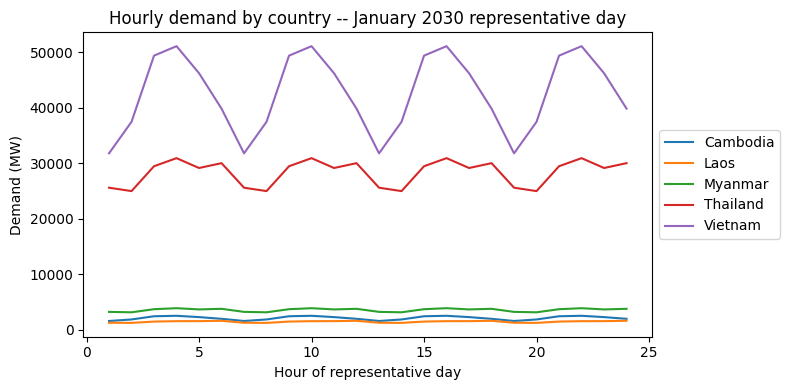

year,2020,2030
zone,,
Cambodia,261445.0,607673.0
Laos,167179.0,414307.0
Myanmar,794647.0,1037239.0
Thailand,6383687.0,8332514.0
Vietnam,6999481.0,12535004.0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

demand = pd.read_csv(SEA_DIR / 'demand.csv')
shape = (
    demand[(demand.year == 2030) & (demand.month == 1) & (demand.hour <= 24)]
    .pivot_table(index='hour', columns='zone', values='value')
)

fig, ax = plt.subplots(figsize=(8, 4))
shape.plot(ax=ax)
ax.set_xlabel('Hour of representative day')
ax.set_ylabel('Demand (MW)')
ax.set_title('Hourly demand by country -- January 2030 representative day')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

# Approximate annual demand totals by country and year
annual = (
    demand.groupby(['zone', 'year'])['value']
    .sum()
    .unstack('year')
    .round(0)
)
annual

## 3. The existing fleet (2020)

What's already built. Vietnam dominates with **21.6 GW of coal** and **16.7 GW of solar**; Thailand has **27.9 GW of gas**. The 57 hydropower stations are split across Laos (41), Vietnam (11), Thailand (4), and Cambodia (1) -- we'll handle them separately below.

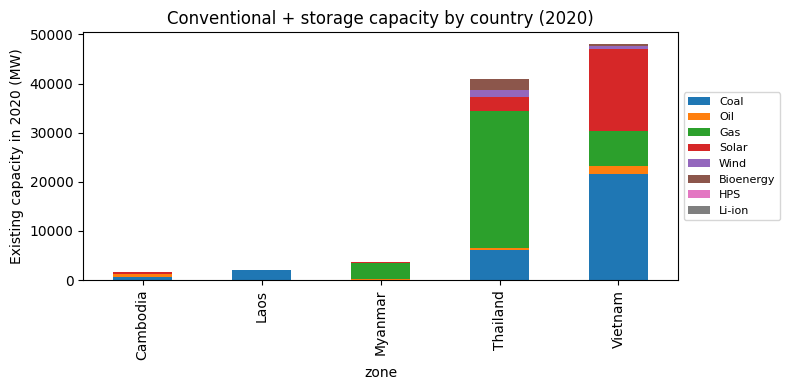

tech,Coal,Oil,Gas,Solar,Wind,Bioenergy,HPS,Li-ion
zone,,,,,,,,
Cambodia,675.0,644.0,0.0,237.0,0.0,31.0,0,0
Laos,1978.0,0.0,0.0,0.0,0.0,0.0,0,0
Myanmar,120.0,25.0,3341.0,180.0,0.0,0.0,0,0
Thailand,6114.0,369.0,27920.0,2856.0,1486.0,2213.0,0,0
Vietnam,21554.0,1706.0,7152.0,16656.0,582.0,365.0,0,0


In [4]:
fleet = pd.read_csv(SEA_DIR / 'tech_existing.csv')

conventional = ['Coal', 'Oil', 'Gas', 'Solar', 'Wind', 'Bioenergy',
                'HPS', 'Li-ion']
fleet_conv = fleet[fleet.tech.isin(conventional)]

stack = (
    fleet_conv
    .pivot_table(index='zone', columns='tech', values='capacity',
                 aggfunc='sum', fill_value=0)
    .reindex(columns=conventional, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 4))
stack.plot.bar(ax=ax, stacked=True)
ax.set_ylabel('Existing capacity in 2020 (MW)')
ax.set_title('Conventional + storage capacity by country (2020)')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
fig.tight_layout()
plt.show()

stack.round(0)

## 4. Per-station hydropower

PREP-SHOT's distinguishing feature is **per-station** hydropower. Each row in `tech_registry.csv` with `carrier='hydro'` is a physical station with its own reservoir, head-discharge curve, and inflow time series. The model tracks water mass balance between cascading stations explicitly. PyPSA, GenX, and similar models aggregate hydropower into a single per-zone tech, losing the cascade physics.

Most stations sit on the Lao Mekong tributaries (the Nam-* series, plus the Xe-Kong, Se-San, Sre Pok cascades extending into Vietnam and Cambodia).

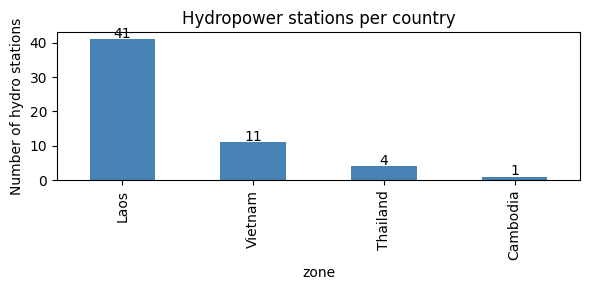

Total hydropower stations: 57
Sample station names:
  Nam_Ou_7
  Nam_Ngay
  Nam_Ou_6
  Nam_Ou_5
  Nam_Pok
  Nam_Ou_4
  Nam_Pha
  Nam_Ko
  ...


In [5]:
stations = pd.read_csv(SEA_DIR / 'reservoir_zone.csv')
stations.columns = [c.strip() for c in stations.columns]
by_zone = stations.groupby('zone').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
by_zone.plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('Number of hydro stations')
ax.set_title('Hydropower stations per country')
for i, v in enumerate(by_zone.values):
    ax.text(i, v + 0.5, str(v), ha='center')
fig.tight_layout()
plt.show()

print(f'Total hydropower stations: {len(stations)}')
print('Sample station names:')
for s in stations.tech.head(8):
    print(f'  {s}')
print('  ...')

In [6]:
# Each station has reservoir-physics parameters: head, capacity
# bounds, storage bounds, generation efficiency. Sample the
# largest 10 stations by capacity:
head = pd.read_csv(SEA_DIR / 'reservoir_head.csv')
cap  = pd.read_csv(SEA_DIR / 'reservoir_capacity_max.csv')
merged = (
    head[['tech', 'head']]
    .merge(cap[['tech', 'capacity_max']], on='tech')
    .merge(stations[['tech', 'zone']], on='tech')
)
merged.columns = ['station', 'head_m', 'capacity_max_MW', 'zone']
merged.sort_values('capacity_max_MW', ascending=False).head(10).round(1)


,station,head_m,capacity_max_MW,zone
14,Mekong_at_Xayabuly,29.0,1260.0,Laos
45,Yali,190.0,720.0,Vietnam
17,Nam_Ngum_2,159.5,615.0,Laos
24,Nam_Theun1,130.0,600.0,Laos
41,Lam_Ta_Khong_P.S.,360.0,500.0,Thailand
15,Nam_Ngum_3,301.0,480.0,Laos
51,Lower_Se_San_2,28.5,400.0,Cambodia
48,Se_San_4,56.0,360.0,Vietnam
29,Xe_Kong_5,180.0,330.0,Laos
40,Xekaman_1,101.2,290.0,Laos


## 5. Inter-country transmission

Existing inter-country transmission capacity (MW). Most flows today route through Laos and Thailand. The transmission candidates table allows any pair to expand.

In [7]:
trans = pd.read_csv(SEA_DIR / 'transmission_existing.csv')
trans = trans[trans.value > 0]
matrix = trans.pivot_table(
    index='zone1', columns='zone2', values='value',
    aggfunc='sum', fill_value=0,
)
matrix.round(0)

zone2,Cambodia,Laos,Thailand,Vietnam
zone1,,,,
Cambodia,0.0,0.0,120.0,400.0
Laos,0.0,0.0,2205.0,248.0
Thailand,120.0,2205.0,0.0,0.0
Vietnam,400.0,248.0,0.0,0.0


## 6. Running a full capacity-expansion solve

This dataset is fully self-contained: `examples/southeast_asia/` ships its own `config.json`, `params.json`, and `input/` -- exactly the same layout as `examples/three_zone/` or `examples/thailand/`. To run a full solve, treat that directory as the working root:

```bash
# from the repo root
cd examples/southeast_asia
python -m prepshot
```

The shipped config uses 288 representative hours x 12 months at 3 head iterations -- the dataset's native resolution. Expect about 30 minutes on commodity hardware. Drop `hour` to 24 and `month` to 1 for a quicker (less accurate) sanity solve. Results land in `examples/southeast_asia/output/baseline.nc`.

**Counterfactual scenarios** without overwriting the baseline:

```bash
# Tighter 2030 carbon cap: prepare a modified file
cd examples/southeast_asia/input
cp policy_carbon_emission_limit.csv policy_carbon_emission_limit_tight.csv
# (then edit the 2030 row's value column to 80000000)

cd ..   # back to examples/southeast_asia
python -m prepshot --carbon_emission_limit=tight
# results -> output/baseline_tight.nc
```

PREP-SHOT registers a CLI flag for every `params.json` key; the flag value is appended as a suffix to the input file name and to the output netCDF. See [Model Inputs/Outputs](../../doc/source/Model_input_output.rst) for the full list of overrideable inputs.

## 7. Post-solve diagnostics: common plots from a solved baseline

Once `python run.py` finishes, results land in
`examples/southeast_asia/output/baseline.nc` (and `.xlsx`). The cells
below load that file and produce the four plots that answer the most
common questions about an expansion-planning result:

1. **Capacity buildout by zone × tech × year**: how the fleet evolves
2. **Generation mix by zone × tech**: what's actually serving demand
3. **Emissions vs the cap**: whether the carbon constraint is binding
4. **Cost breakdown**: where the NPV dollars go

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read from the .xlsx mirror so the cell works without a netCDF4
# build (the .xlsx contains the same numbers as baseline.nc).
OUT = SEA_DIR.parent / 'output' / 'baseline.xlsx'
if not OUT.exists():
    raise FileNotFoundError(
        f'No solved baseline at {OUT}. Run `python run.py` from '
        f'examples/southeast_asia/ first.'
    )
xl = pd.ExcelFile(OUT)
print('Sheets:', xl.sheet_names[:8], '...')

Sheets: ['trans_export', 'gen', 'install', 'carbon', 'charge', 'cost_var_breakdown', 'cost_fix_breakdown', 'cost_newtech_breakdown'] ...


### 7.1 Capacity buildout

Per-zone stacked bars by technology, comparing 2020 (existing) to
2030 (after expansion). Cambodia's 2030 column is the most striking
— it grows from ~2 GW to ~140 GW because the model uses Cambodia
as a renewable-rich exporter to Vietnam and Thailand once the
carbon cap binds.

/var/folders/y_/ypyrt83d1hl9fhjtt_ftpwg00000gn/T/ipykernel_11433/768360123.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


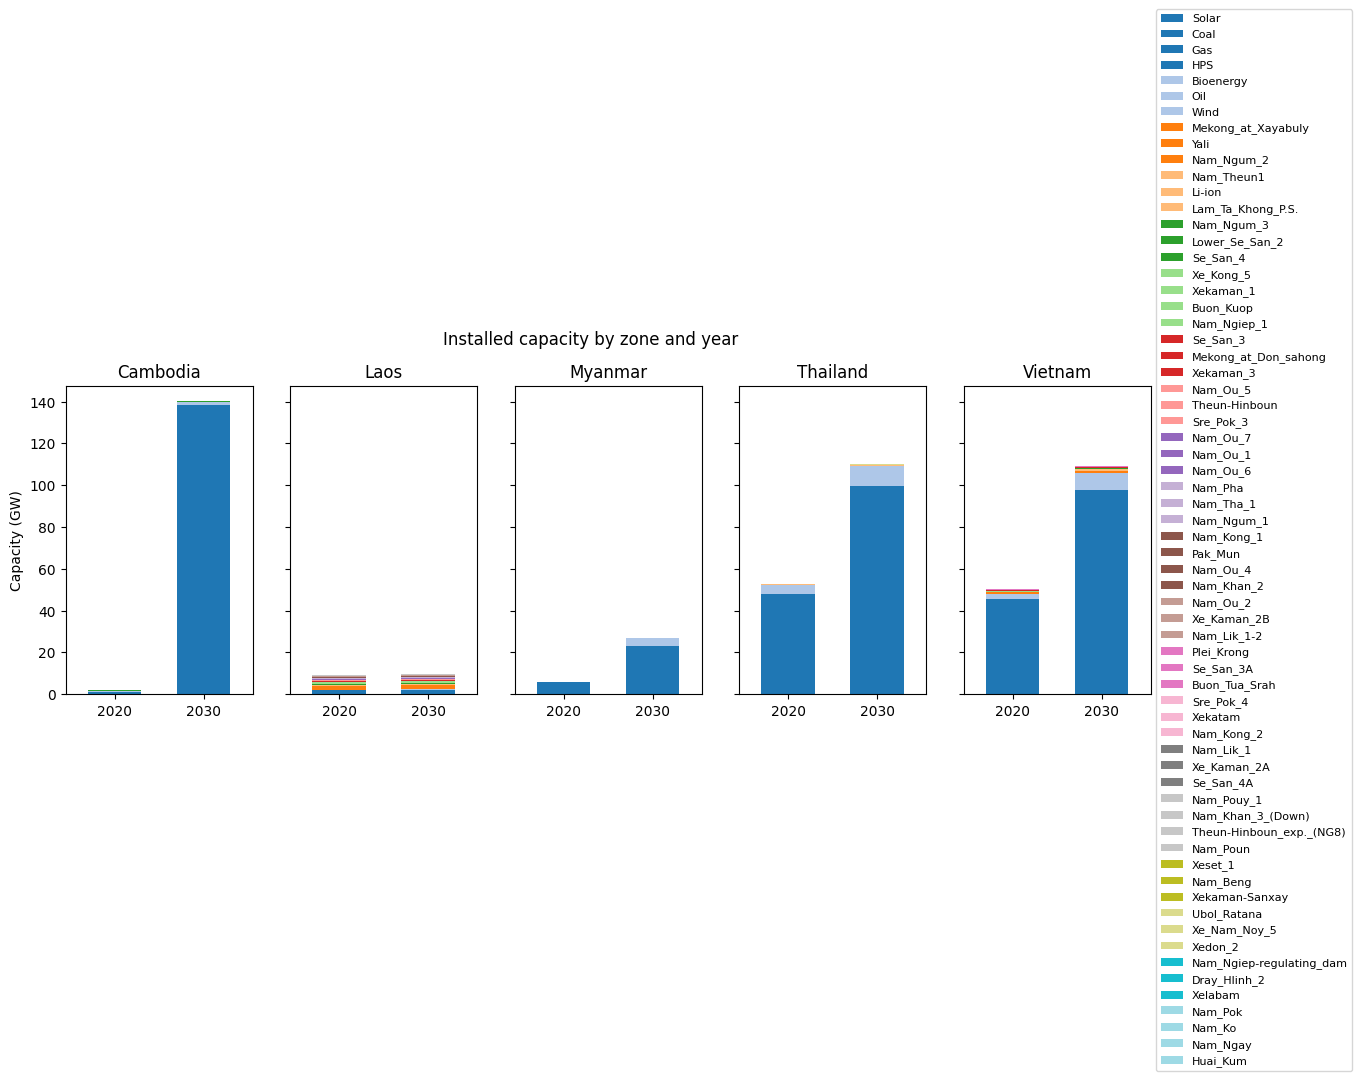

In [9]:
inst = pd.read_excel(xl, 'install')
techs_order = (inst.groupby('tech')['install']
               .sum().sort_values(ascending=False).index.tolist())
zones = sorted(inst['zone'].unique())

fig, axes = plt.subplots(1, len(zones), figsize=(14, 4), sharey=True)
for ax, z in zip(axes, zones):
    sub = (inst[inst.zone == z]
           .pivot(index='year', columns='tech', values='install')
           .fillna(0))
    sub = sub.reindex(columns=[t for t in techs_order if t in sub.columns])
    (sub / 1000).plot(
        kind='bar', stacked=True, ax=ax,
        legend=(z == zones[-1]), width=0.6, colormap='tab20',
    )
    ax.set_title(z)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('Capacity (GW)' if z == zones[0] else '')
axes[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5),
                fontsize=8, ncol=1)
fig.suptitle('Installed capacity by zone and year', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Generation mix

Same layout, but summing `gen` over (hour, month) to get annual TWh.
The point of the chart: which technologies actually run, vs. which
are just installed (peakers may have lots of capacity but very low
utilization).

/var/folders/y_/ypyrt83d1hl9fhjtt_ftpwg00000gn/T/ipykernel_11433/428247067.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


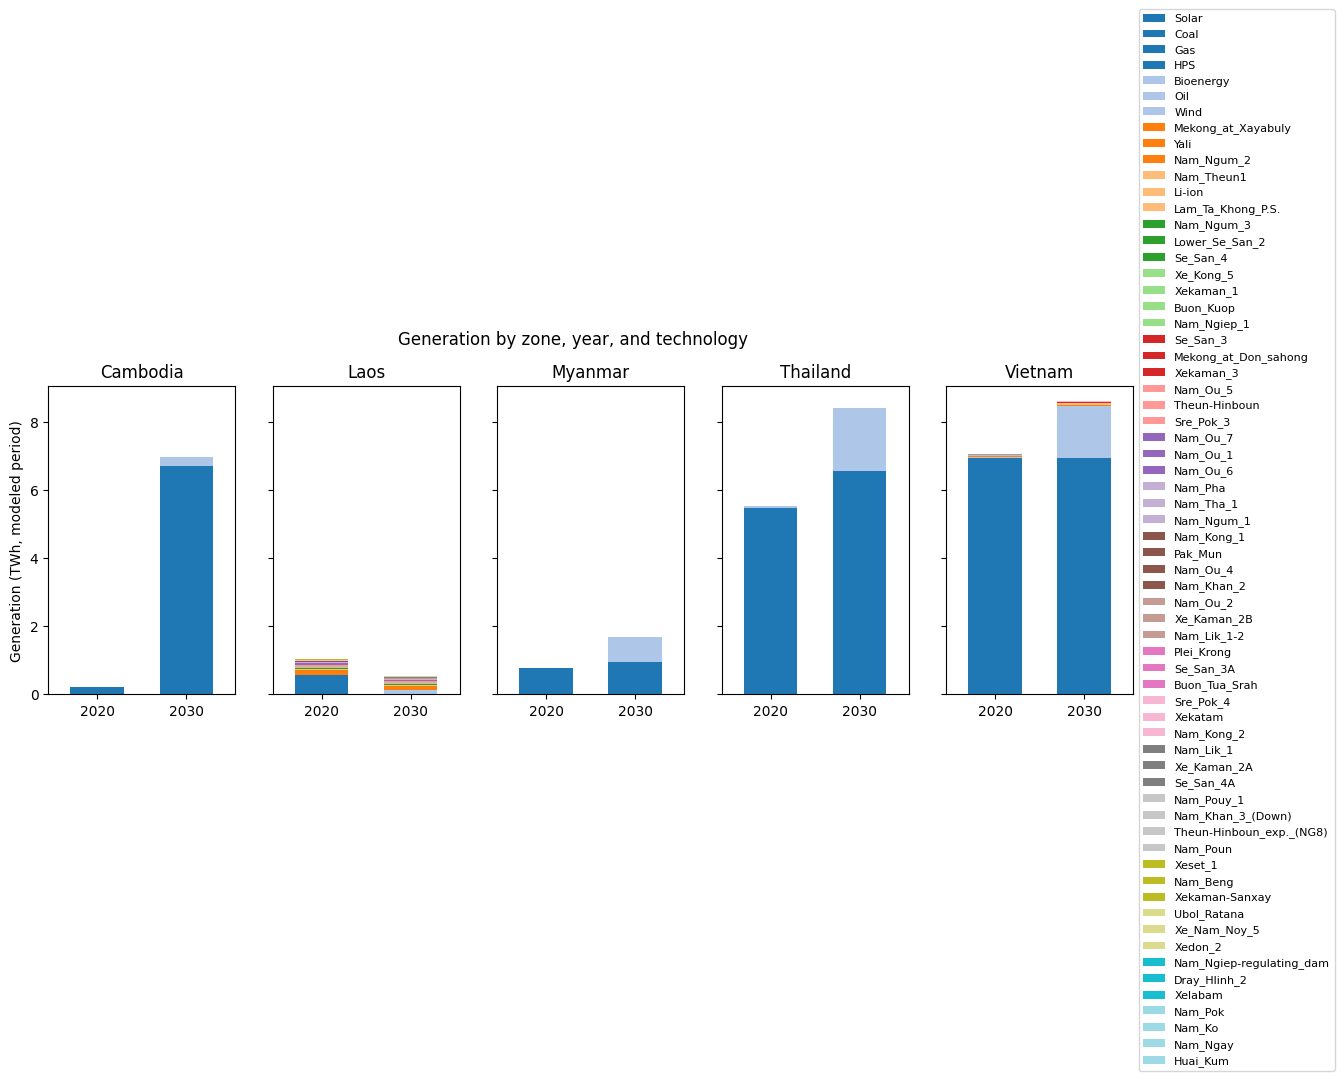

In [10]:
gen = pd.read_excel(xl, 'gen')
# gen is keyed by (hour, month, year, zone, tech); aggregate to
# annual TWh per (year, zone, tech).
g_annual = gen.groupby(['year', 'zone', 'tech'])['gen'].sum().reset_index()
g_annual['gen_TWh'] = g_annual['gen'] / 1e6

fig, axes = plt.subplots(1, len(zones), figsize=(14, 4), sharey=True)
for ax, z in zip(axes, zones):
    sub = (g_annual[g_annual.zone == z]
           .pivot(index='year', columns='tech', values='gen_TWh')
           .fillna(0))
    sub = sub.reindex(columns=[t for t in techs_order if t in sub.columns])
    sub.plot(
        kind='bar', stacked=True, ax=ax,
        legend=(z == zones[-1]), width=0.6, colormap='tab20',
    )
    ax.set_title(z)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('Generation (TWh, modeled period)' if z == zones[0] else '')
axes[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5),
                fontsize=8, ncol=1)
fig.suptitle('Generation by zone, year, and technology', y=1.02)
plt.tight_layout()
plt.show()

### 7.3 Emissions vs the carbon cap

The system-wide carbon cap is `inf` in 2020 (unconstrained) and
146 MtCO2 in 2030. Emissions in 2030 should sit exactly on the cap
if it's binding — that's how you can tell the constraint is doing
work.

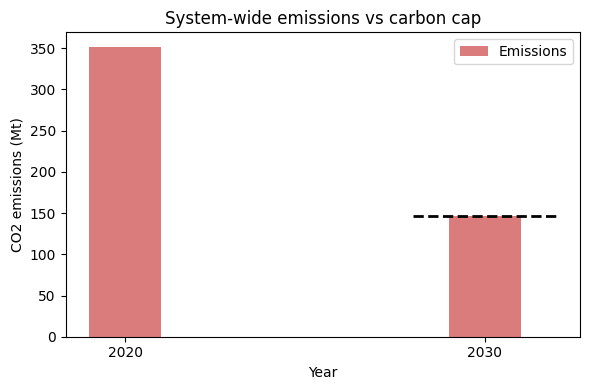

 year  carbon_Mt
 2020 351.715468
 2030 146.000000


In [11]:
co2 = pd.read_excel(xl, 'carbon')
co2['carbon_Mt'] = co2['carbon'] / 1e6

cap = pd.read_csv(SEA_DIR / 'policy_carbon_emission_limit.csv')
cap_finite = cap[cap['value'] != float('inf')].copy()
cap_finite['cap_Mt'] = cap_finite['value'] / 1e6

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(co2['year'], co2['carbon_Mt'], width=2,
       color='#cc4444', alpha=0.7, label='Emissions')
for _, row in cap_finite.iterrows():
    ax.hlines(row['cap_Mt'], row['year'] - 2, row['year'] + 2,
              colors='black', linestyles='--', linewidth=2,
              label='Cap' if _ == 0 else None)
ax.set_xlabel('Year')
ax.set_ylabel('CO2 emissions (Mt)')
ax.set_title('System-wide emissions vs carbon cap')
ax.set_xticks(co2['year'])
ax.legend()
plt.tight_layout()
plt.show()

print(co2[['year', 'carbon_Mt']].to_string(index=False))

### 7.4 Cost breakdown

Total NPV cost is the sum of:

- `cost_var`: variable O&M + fuel
- `cost_fix`: fixed O&M on existing + new fleet
- `cost_newtech`: capex annuity for new generation
- `cost_newline`: capex annuity for new transmission
- `−income`: water-withdrawal revenue (subtracted from cost)

All values are NPV-discounted to year_min (2020).

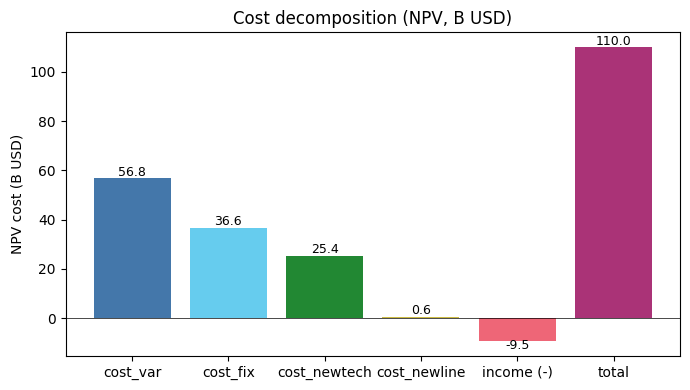

In [12]:
components = ['cost_var', 'cost_fix', 'cost_newtech', 'cost_newline']
values = [pd.read_excel(xl, c).iloc[0, 1] / 1e9 for c in components]
income = pd.read_excel(xl, 'income').iloc[0, 1] / 1e9
total = pd.read_excel(xl, 'cost').iloc[0, 1] / 1e9

labels = components + ['income (-)', 'total']
vals = values + [-income, total]
colors = ['#4477aa', '#66ccee', '#228833', '#ccbb44',
          '#ee6677', '#aa3377']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, vals, color=colors)
for i, v in enumerate(vals):
    ax.text(i, v + (1 if v >= 0 else -3), f'{v:,.1f}',
            ha='center', fontsize=9)
ax.set_ylabel('NPV cost (B USD)')
ax.set_title('Cost decomposition (NPV, B USD)')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. What this case study shows that aggregated models miss

Three things this dataset reveals that you couldn't get from PyPSA's or GenX's standard hydro abstractions:

**1. Cascade interactions across borders.** A new dam upstream in Laos changes downstream flow at every station below it -- potentially across the Cambodia / Vietnam border. The 57-station model captures this; an aggregated 'Hydro_Laos' tech does not.

**2. Endogenous water-head dynamics.** Each station's generation efficiency depends on its current reservoir level via the tailrace-discharge and forebay-volume curves. PREP-SHOT's head-iteration loop solves the LP, recomputes heads from the operational schedule, and re-solves until convergence.

**3. Where carbon abatement actually lives.** Because the model tracks each zone's emissions separately under a system-wide cap, the optimization shows where the cheapest abatement is across borders -- not just inside each country's boundary. For the Mekong, the answer is usually 'don't build new Vietnam coal; import Lao hydro instead' -- but the optimal trade depends on transmission build cost, hydropower seasonality, and carbon-cap tightness, all of which the model handles endogenously.

## Where to next

- [Quickstart](../../doc/source/Quickstart.ipynb) -- the simpler 3-zone walkthrough with a full executed solve.
- [Model Inputs/Outputs](../../doc/source/Model_input_output.rst) -- every input and output documented.
- [Mathematical Notation](../../doc/source/Mathematical_notations.rst) -- the underlying linear program.
- [Changelog](../../doc/source/Changelog.rst) -- v1.7 hydropower first-class, v1.8 PyPSA-style behavior flags, v1.9 finance module + LMPs.

If you used PREP-SHOT in published work, please cite it (see the [Citation Guide](../../doc/source/Citations.rst)). Issues, discussions, and PRs welcome at [github.com/PREP-NexT/PREP-SHOT](https://github.com/PREP-NexT/PREP-SHOT).